# Saffman double-ARP CZ gate：exact backend 验证

这个 notebook 用仓库的 `backend="exact"` 做两原子 state-vector simulation，复现 Saffman 等人在 arXiv:1912.02977 中的 symmetric Rydberg CZ double-ARP protocol。

本地能级写成 `|0>`, `|1>`, `|r>`：`|0>` 是 dark qubit state，pulse 只驱动 `|1> <-> |r>`。也就是说 active transition 正是 passage 里的 `1-r` ARP；保留 `|0>` 只是为了能计算 CZ/Bell fidelity。

Hamiltonian convention 取

$$
H(t)=\sum_{i=1}^2 \left[\frac{\Omega(t)}{2}\left(|r_i\rangle\langle 1_i|+|1_i\rangle\langle r_i|\right)+\Delta(t)n_i^r\right]
+B n_1^r n_2^r .
$$

`Omega(t)` 是两个四次 super-Gaussian bumps；每一半 ARP 的 detuning 都从 `-Delta_max` 扫到 `+Delta_max`，中点 `T/2` 在 `Omega=0` 处把 detuning reset 回负值。

本 notebook 按 `scripts/notebooks/run_quench_benchmark.ipynb` 的风格写成顺序脚本：先定义参数和现有 `DigitalAnalogProtocol` segments，再跑 exact baseline、画 population、画 fidelity sensitivity。


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import make_chain
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol, Segment

plt.rcParams.update({"figure.dpi": 120})


## 1. Pulse 和系统参数

角频率统一用 rad/s；图上的频率单位再除以 `2*pi` 转成 MHz。`sigma = 0.175 T` 按论文 Fig. 2 caption；每个 ARP pulse 长度为 `T/2`。

`B_POP` 用来画 Fig. 2 风格的 population cycle；`B_GATE` 用来做高 blockade Bell fidelity。这里用 `make_chain(2, spacing_um=1)` 且设置 `C6=B`，所以两原子相互作用正好是 `B=C6/R^6`。


In [2]:
pi = np.pi
MHz = 2.0 * pi * 1e6
us = 1e-6

Omega_max = 17.0 * MHz
Delta_max = 23.0 * MHz
T_gate = 0.54 * us
T_pulse = 0.5 * T_gate
sigma = 0.175 * T_gate

B_POP = 100.0 * MHz       # Fig. 2 population example
B_GATE = 3000.0 * MHz     # high-fidelity Bell example in the paper text
N_STEPS = 320             # exact backend midpoint piecewise-constant steps
N_SCAN = 13

geom = make_chain(2, spacing_um=1.0)


## 2. Double ARP protocol

这里不定义新的 protocol class，而是使用当前仓库已有的 `DigitalAnalogProtocol`。连续 double-ARP 波形在每个 exact time step 的中点采样，写成 `N_STEPS` 个 piecewise-constant `Segment`。

`DigitalAnalogProtocol` 的约定是 Hamiltonian 中有 `-delta_R n_r`，所以为了实现上面写的 `+Delta(t)n_r`，segment 里填入 `delta_R=-Delta(t)`。


In [3]:
arp_offset_a = np.exp(-((T_pulse / 2.0) ** 4) / sigma**4)

def local_arp_time(t):
    t = float(np.clip(t, 0.0, T_gate))
    return t if t < T_pulse else t - T_pulse

def arp_omega(t, omega_scale=1.0):
    u = local_arp_time(t)
    env = (np.exp(-((u - T_pulse / 2.0) ** 4) / sigma**4) - arp_offset_a) / (1.0 - arp_offset_a)
    return float(omega_scale) * Omega_max * env

def arp_delta(t, delta_offset=0.0):
    u = local_arp_time(t)
    return Delta_max * np.sin(pi * (u / T_pulse - 0.5)) + float(delta_offset)

def make_arp_protocol(omega_scale=1.0, delta_offset=0.0, n_steps=N_STEPS):
    n_steps = int(n_steps)
    dt = T_gate / n_steps
    segments = []
    for k in range(n_steps):
        t_mid = (k + 0.5) * dt
        segments.append(
            Segment(
                duration=dt,
                omega_R=arp_omega(t_mid, omega_scale=omega_scale),
                delta_R=-arp_delta(t_mid, delta_offset=delta_offset),
                omega_hf=0.0,
                delta_hf=0.0,
            )
        )
    return DigitalAnalogProtocol(segments, n_steps=n_steps)

def make_arp_system(B=B_GATE, omega_scale=1.0, delta_offset=0.0, n_steps=N_STEPS):
    protocol = make_arp_protocol(
        omega_scale=omega_scale,
        delta_offset=delta_offset,
        n_steps=n_steps,
    )
    return rg.RydbergSystem.from_lattice(
        geom,
        "01r",
        interaction=InteractionSpec(C6=float(B), mode="all"),
        protocol=protocol,
    )

base_system = make_arp_system(B=B_GATE)
base_protocol = base_system.protocol


## 3. Computational basis 和 Bell benchmark

Hadamard 只作用在 qubit subspace `|0>, |1>`，对 `|r>` 保持不变。Bell benchmark 使用论文里的流程：从 `|11>` 出发，先对两个 qubit 做 Hadamard，再施加 Rydberg CZ operation，最后对 target qubit 做 Hadamard。理想输出是

$$
|B\rangle=(|00\rangle+|11\rangle)/\sqrt2.
$$


In [4]:
I1 = np.eye(3, dtype=complex)
H_qubit = (1.0 / np.sqrt(2.0)) * np.array(
    [[1.0, 1.0, 0.0],
     [1.0, -1.0, 0.0],
     [0.0, 0.0, np.sqrt(2.0)]],
    dtype=complex,
)
H_both = np.kron(H_qubit, H_qubit)
H_target = np.kron(I1, H_qubit)

ket00 = base_system.product_state(["0", "0"])
ket01 = base_system.product_state(["0", "1"])
ket10 = base_system.product_state(["1", "0"])
ket11 = base_system.product_state(["1", "1"])
ket0r = base_system.product_state(["0", "r"])
ketr0 = base_system.product_state(["r", "0"])
ket1r = base_system.product_state(["1", "r"])
ketr1 = base_system.product_state(["r", "1"])
ketrr = base_system.product_state(["r", "r"])
ket_dplus = (ket1r + ketr1) / np.sqrt(2.0)
ket_bell = (ket00 + ket11) / np.sqrt(2.0)

comp_states = [ket00, ket01, ket10, ket11]
comp_labels = ["00", "01", "10", "11"]

def run_exact_arp(psi0, B=B_GATE, omega_scale=1.0, delta_offset=0.0, t_eval=None, n_steps=N_STEPS):
    system = make_arp_system(
        B=B,
        omega_scale=omega_scale,
        delta_offset=delta_offset,
        n_steps=n_steps,
    )
    return rg.simulate(
        system,
        [],
        psi0,
        backend="exact",
        t_eval=t_eval,
        backend_options={"n_steps": int(n_steps)},
    )

def bell_fidelity(B=B_GATE, omega_scale=1.0, delta_offset=0.0, n_steps=N_STEPS):
    psi_in = H_both @ ket11
    res = run_exact_arp(
        psi_in,
        B=B,
        omega_scale=omega_scale,
        delta_offset=delta_offset,
        n_steps=n_steps,
    )
    psi_out = H_target @ res.psi_final
    return float(abs(np.vdot(ket_bell, psi_out)) ** 2)


## 4. Pulse shape

蓝色是两个 `Omega(t)` bumps；红色是两段 `-Delta_max -> +Delta_max` sweep。中点 reset 发生在 `Omega=0`，所以不会在开耦合时突然混合裸态。


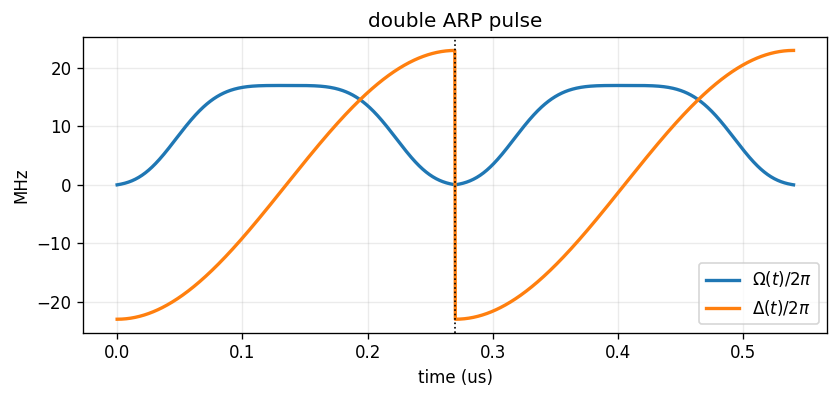

In [5]:
t_plot = np.linspace(0.0, T_gate, 1201)
omega_plot = np.asarray([arp_omega(t) / MHz for t in t_plot])
delta_plot = np.asarray([arp_delta(t) / MHz for t in t_plot])

fig, ax = plt.subplots(figsize=(8.0, 3.2))
ax.plot(t_plot / us, omega_plot, lw=2.0, label=r"$\Omega(t)/2\pi$")
ax.plot(t_plot / us, delta_plot, lw=2.0, label=r"$\Delta(t)/2\pi$")
ax.axvline(0.5 * T_gate / us, color="k", ls=":", lw=1.0)
ax.set_xlabel("time (us)")
ax.set_ylabel("MHz")
ax.set_title("double ARP pulse")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 5. Population cycle：Fig. 2 的物理图像

这里用 `B_POP/2pi = 100 MHz`，对应论文 Fig. 2 的 population illustration。`|10>` 分支走 `|10> -> |r0> -> |10>`；`|11>` 分支主要走 `|11> -> (|1r>+|r1>)/sqrt(2) -> |11>`，并且有小的 `|rr>` leakage。


population traces elapsed: 1.67 s


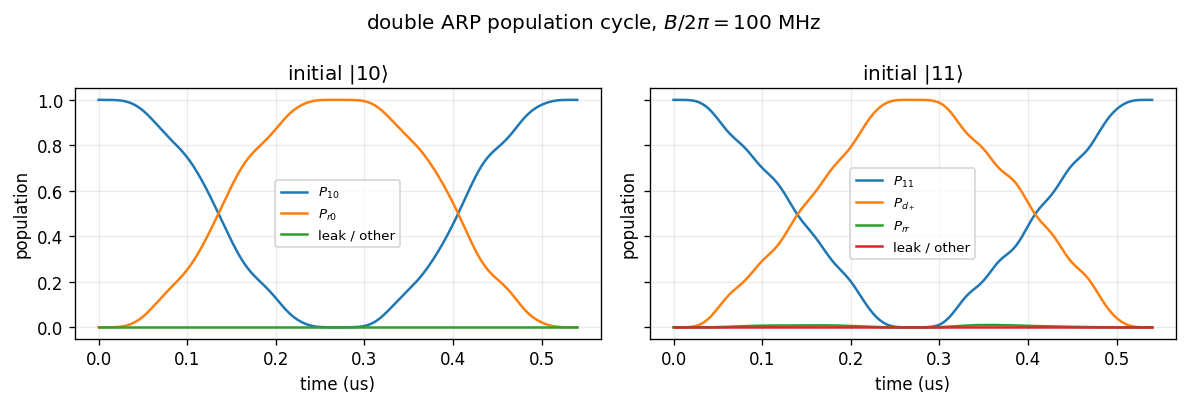

In [6]:
t_eval_pop = np.linspace(0.0, T_gate, N_STEPS + 1)

_t0 = time.perf_counter()
res_10 = run_exact_arp(ket10, B=B_POP, t_eval=t_eval_pop, n_steps=N_STEPS)
res_11 = run_exact_arp(ket11, B=B_POP, t_eval=t_eval_pop, n_steps=N_STEPS)
print(f"population traces elapsed: {time.perf_counter() - _t0:.2f} s")

states_10 = np.asarray(res_10.states)
states_11 = np.asarray(res_11.states)

P_10 = np.abs(states_10 @ ket10.conj()) ** 2
P_r0 = np.abs(states_10 @ ketr0.conj()) ** 2
P_dark_10 = 1.0 - P_10 - P_r0

P_11 = np.abs(states_11 @ ket11.conj()) ** 2
P_dplus = np.abs(states_11 @ ket_dplus.conj()) ** 2
P_rr = np.abs(states_11 @ ketrr.conj()) ** 2
P_dark_11 = 1.0 - P_11 - P_dplus - P_rr

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4), sharex=True, sharey=True)
axes[0].plot(res_10.times / us, P_10, label=r"$P_{10}$")
axes[0].plot(res_10.times / us, P_r0, label=r"$P_{r0}$")
axes[0].plot(res_10.times / us, P_dark_10, label=r"leak / other")
axes[0].set_title(r"initial $|10\rangle$")

axes[1].plot(res_11.times / us, P_11, label=r"$P_{11}$")
axes[1].plot(res_11.times / us, P_dplus, label=r"$P_{d_+}$")
axes[1].plot(res_11.times / us, P_rr, label=r"$P_{rr}$")
axes[1].plot(res_11.times / us, P_dark_11, label=r"leak / other")
axes[1].set_title(r"initial $|11\rangle$")

for ax in axes:
    ax.set_xlabel("time (us)")
    ax.set_ylabel("population")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle(rf"double ARP population cycle, $B/2\pi={B_POP / MHz:.0f}$ MHz")
fig.tight_layout()
plt.show()


## 6. Gate phases 和 Bell fidelity

下面用 `B_GATE/2pi = 3 GHz` 打印计算基返回概率、相位和 Bell fidelity。这个 exact backend run 是 coherent upper-bound：没有 Rydberg decay、intermediate-state scattering、Doppler sampling 或 Stark shift compensation。


In [7]:
_t0 = time.perf_counter()
U_eff = np.zeros((4, 4), dtype=complex)
for col, psi0 in enumerate(comp_states):
    psi_out = run_exact_arp(psi0, B=B_GATE, n_steps=N_STEPS).psi_final
    for row, bra in enumerate(comp_states):
        U_eff[row, col] = np.vdot(bra, psi_out)

phase_diag = np.angle(np.diag(U_eff))
diag_prob = np.abs(np.diag(U_eff)) ** 2
comp_return_prob = np.sum(np.abs(U_eff) ** 2, axis=0)
phi_ent = np.angle(np.exp(1j * (phase_diag[3] - phase_diag[1] - phase_diag[2] + phase_diag[0])))
F0 = bell_fidelity(B=B_GATE, n_steps=N_STEPS)

print(f"gate baseline elapsed: {time.perf_counter() - _t0:.2f} s")
print(f"B/2pi = {B_GATE / MHz:.0f} MHz, Bell fidelity = {F0:.8f}, infidelity = {1.0 - F0:.3e}")
print("state   diag_prob      comp_return      phase/pi")
for label, p_diag, p_comp, ph in zip(comp_labels, diag_prob, comp_return_prob, phase_diag / pi):
    print(f"|{label}>   {p_diag:10.8f}    {p_comp:10.8f}    {ph:10.6f}")
print(f"entangling phase/pi = {phi_ent / pi:.6f}")
print("\nEffective computational block:")
print(np.round(U_eff, 4))


gate baseline elapsed: 7.56 s
B/2pi = 3000 MHz, Bell fidelity = 0.99960552, infidelity = 3.945e-04
state   diag_prob      comp_return      phase/pi
|00>   1.00000000    1.00000000     -0.000000
|01>   0.99994223    0.99994223     -1.000000
|10>   0.99994223    0.99994223     -1.000000
|11>   0.99994645    0.99994645     -0.986203
entangling phase/pi = -0.986203

Effective computational block:
[[ 1.   -0.j      0.   +0.j      0.   +0.j      0.   +0.j    ]
 [ 0.   +0.j     -1.   -0.j      0.   +0.j      0.   +0.j    ]
 [ 0.   +0.j      0.   +0.j     -1.   -0.j      0.   +0.j    ]
 [ 0.   +0.j      0.   +0.j      0.   +0.j     -0.999-0.0433j]]


## 7. Fidelity sensitivity：`Omega` 和 detuning

第一张图扫描 Rabi 幅度 `Omega -> s Omega`，范围是 `±5%`。第二张图扫描静态 detuning offset，范围是 `±200 kHz`。这对应论文中用来展示 ARP robustness 的两个误差轴。


In [ ]:
omega_scales = np.linspace(0.95, 1.05, N_SCAN)
delta_offsets_hz = np.linspace(-0.2e6, 0.2e6, N_SCAN)

_t0 = time.perf_counter()
F_omega = np.asarray([
    bell_fidelity(B=B_GATE, omega_scale=float(scale), delta_offset=0.0, n_steps=N_STEPS)
    for scale in omega_scales
])
F_delta = np.asarray([
    bell_fidelity(B=B_GATE, omega_scale=1.0, delta_offset=2.0 * pi * float(offset_hz), n_steps=N_STEPS)
    for offset_hz in delta_offsets_hz
])
print(f"sensitivity scan elapsed: {time.perf_counter() - _t0:.2f} s")
print(f"Omega scan: min F = {F_omega.min():.8f}, max loss from center = {F_omega[len(F_omega)//2] - F_omega.min():.3e}")
print(f"Delta scan: min F = {F_delta.min():.8f}, max loss from center = {F_delta[len(F_delta)//2] - F_delta.min():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4))
axes[0].plot((omega_scales - 1.0) * 100.0, F_omega, "o-", lw=1.8)
axes[0].axvline(0.0, color="k", ls=":", lw=1.0)
axes[0].set_xlabel(r"$\Omega$ variation (%)")
axes[0].set_ylabel("Bell fidelity")
axes[0].set_title(r"Rabi amplitude robustness")
axes[0].grid(alpha=0.25)

axes[1].plot(delta_offsets_hz / 1e3, F_delta, "s-", lw=1.8, color="tab:red")
axes[1].axvline(0.0, color="k", ls=":", lw=1.0)
axes[1].set_xlabel(r"detuning offset / $2\pi$ (kHz)")
axes[1].set_ylabel("Bell fidelity")
axes[1].set_title(r"detuning robustness")
axes[1].grid(alpha=0.25)

fig.suptitle(rf"double ARP CZ sensitivity, $B/2\pi={B_GATE / MHz:.0f}$ MHz")
fig.tight_layout()
plt.show()


## 8. 读图方式

- `B_POP = 100 MHz` 的 population plot 用来恢复 Fig. 2 的直观图像。
- `B_GATE = 3 GHz` 的 fidelity plot 用来检查高 blockade 下 Bell fidelity 对 `Omega` 和 detuning offset 的鲁棒性。
- 如果把 `B_GATE` 改成 `100 MHz`，`|rr>` leakage 会明显增大，Bell fidelity 会下降；这不是 pulse 形状错误，而是 blockade 不够强。
- 这里没有加入 Rydberg decay、intermediate-state scattering、Doppler sampling 或 Stark shift compensation；这些会把 coherent upper-bound fidelity 降低到更接近论文的 full error model。
